In [1]:
!pip install datasets


Load and Inspect the Data

In [13]:
from datasets import load_dataset
import pandas as pd

# Load the dataset (this loads all available splits)
dataset = load_dataset("lukebarousse/data_jobs")

# Combine all splits into a single pandas DataFrame
# (if there are multiple splits like 'train', 'test', etc.)
all_splits = []
for split in dataset.keys():
    df_split = dataset[split].to_pandas()
    all_splits.append(df_split)

# Concatenate all splits into one DataFrame
jobs_df = pd.concat(all_splits, ignore_index=True)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   job_title_short        785741 non-null  object 
 1   job_title              785740 non-null  object 
 2   job_location           784696 non-null  object 
 3   job_via                785733 non-null  object 
 4   job_schedule_type      773074 non-null  object 
 5   job_work_from_home     785741 non-null  bool   
 6   search_location        785741 non-null  object 
 7   job_posted_date        785741 non-null  object 
 8   job_no_degree_mention  785741 non-null  bool   
 9   job_health_insurance   785741 non-null  bool   
 10  job_country            785692 non-null  object 
 11  salary_rate            33067 non-null   object 
 12  salary_year_avg        22003 non-null   float64
 13  salary_hour_avg        10662 non-null   float64
 14  company_name           785723 non-nu

In [23]:
# Basic info
jobs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  category      
 1   job_title              785741 non-null  category      
 2   job_location           785741 non-null  object        
 3   job_via                785733 non-null  category      
 4   job_schedule_type      785741 non-null  category      
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785741 non-null  category      
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

In [22]:
jobs_df.head()


,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, Ct",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,None,NaN,NaN,Boehringer Ingelheim,[],{}
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,None,NaN,NaN,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...",{}
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,None,NaN,NaN,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...",{}
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, Tx",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,None,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...",{}
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, Dc",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,None,NaN,NaN,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...",{}


In [24]:
# Check for missing values
print(jobs_df.isnull().sum())


job_title_short               0
job_title                     0
job_location                  0
job_via                       8
job_schedule_type             0
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                   0
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                  0
job_skills                    0
job_type_skills               0
dtype: int64


In [25]:
# Check unique values for categorical columns
categorical_cols = ['job_title_short', 'job_title', 'job_location', 'job_via',
                    'job_schedule_type', 'job_work_from_home', 'job_no_degree_mention',
                    'job_health_insurance', 'job_country']
for col in categorical_cols:
    print(f"{col} - Unique Values: {jobs_df[col].nunique()}")

job_title_short - Unique Values: 10
job_title - Unique Values: 234674
job_location - Unique Values: 17213
job_via - Unique Values: 7903
job_schedule_type - Unique Values: 48
job_work_from_home - Unique Values: 2
job_no_degree_mention - Unique Values: 2
job_health_insurance - Unique Values: 2
job_country - Unique Values: 161


Clean the Data

1.Handle Missing Values

In [26]:
# Fill missing first
jobs_df['job_location'].fillna('Unknown', inplace=True)
jobs_df['job_schedule_type'].fillna('Unknown', inplace=True)
jobs_df['job_country'].fillna('Unknown', inplace=True)
jobs_df['job_title'].fillna('Unknown', inplace=True)
jobs_df['company_name'].fillna('Unknown', inplace=True)

# Fill missing job_skills and job_type_skills with empty lists
jobs_df['job_skills'] = jobs_df['job_skills'].apply(lambda x: [] if x is None else x)
jobs_df['job_type_skills'] = jobs_df['job_type_skills'].apply(lambda x: {} if x is None else x)
# Check for missing values
print(jobs_df.isnull().sum())



/tmp/ipython-input-4161438270.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  jobs_df['job_location'].fillna('Unknown', inplace=True)
/tmp/ipython-input-4161438270.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)',

job_title_short               0
job_title                     0
job_location                  0
job_via                       8
job_schedule_type             0
job_work_from_home            0
search_location               0
job_posted_date               0
job_no_degree_mention         0
job_health_insurance          0
job_country                   0
salary_rate              752674
salary_year_avg          763738
salary_hour_avg          775079
company_name                  0
job_skills                    0
job_type_skills               0
dtype: int64


2.Fix Data Types:

In [27]:
# Booleans
bool_cols = ['job_work_from_home', 'job_no_degree_mention', 'job_health_insurance']
jobs_df[bool_cols] = jobs_df[bool_cols].astype(bool)

# Date
jobs_df['job_posted_date'] = pd.to_datetime(jobs_df['job_posted_date'], errors='coerce')

# Categorical
cat_cols = ['job_title_short', 'job_title', 'job_location', 'job_via',
            'job_schedule_type', 'job_country']
for col in cat_cols:
    jobs_df[col] = jobs_df[col].astype('category')

def safe_parse_dict(x):
    if pd.isna(x) or x is None:
        return {}  # replace missing with empty dict
    if isinstance(x, dict):
        return x
    try:
        return ast.literal_eval(x)  # safely convert string to dict
    except:
        return {}

jobs_df['job_type_skills'] = jobs_df['job_type_skills'].apply(safe_parse_dict)

#job_skills is a list
jobs_df['job_skills'] = jobs_df['job_skills'].apply(lambda x: [] if x is None else x)

# Clean job_location values
jobs_df['job_location'] = jobs_df['job_location'].astype(str).str.strip().str.title()

jobs_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  category      
 1   job_title              785741 non-null  category      
 2   job_location           785741 non-null  object        
 3   job_via                785733 non-null  category      
 4   job_schedule_type      785741 non-null  category      
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785741 non-null  category      
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

Feature Engineering

In [28]:
# Skill Features
# ========== Number of skills ============
jobs_df['num_skills'] = jobs_df['job_skills'].apply(len)

# Number of categorized skills
jobs_df['num_type_skills'] = jobs_df['job_type_skills'].apply(lambda x: sum(len(v) for v in x.values()))

# ========== Date Features ================
jobs_df['posted_year'] = jobs_df['job_posted_date'].dt.year
jobs_df['posted_month'] = jobs_df['job_posted_date'].dt.month
jobs_df['posted_dayofweek'] = jobs_df['job_posted_date'].dt.dayofweek

# ========== Salary Features ===============
jobs_df['salary_year_avg'].fillna(jobs_df['salary_year_avg'].median(), inplace=True)
jobs_df['salary_hour_avg'].fillna(jobs_df['salary_hour_avg'].median(), inplace=True)

jobs_df.head(5)


/tmp/ipython-input-602352678.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  jobs_df['salary_year_avg'].fillna(jobs_df['salary_year_avg'].median(), inplace=True)
/tmp/ipython-input-602352678.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,...,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,num_skills,num_type_skills,posted_year,posted_month,posted_dayofweek
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, Ct",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,...,115000.0,45.98,Boehringer Ingelheim,[],{},0,0,2023,6,4
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,...,115000.0,45.98,Hewlett Packard Enterprise,"['r', 'python', 'sql', 'nosql', 'power bi', 't...",{},54,0,2023,1,5
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,...,115000.0,45.98,ALPHA Augmented Services,"['python', 'sql', 'c#', 'azure', 'airflow', 'd...",{},85,0,2023,10,1
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, Tx",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,...,115000.0,45.98,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...",{},76,0,2023,7,1
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, Dc",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,...,115000.0,45.98,Kristina Daniel,"['bash', 'python', 'oracle', 'aws', 'ansible',...",{},84,0,2023,8,0


Exploratory Data Analysis (EDA)

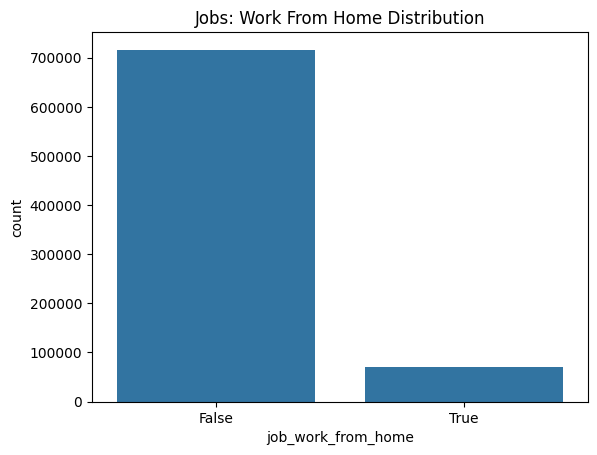

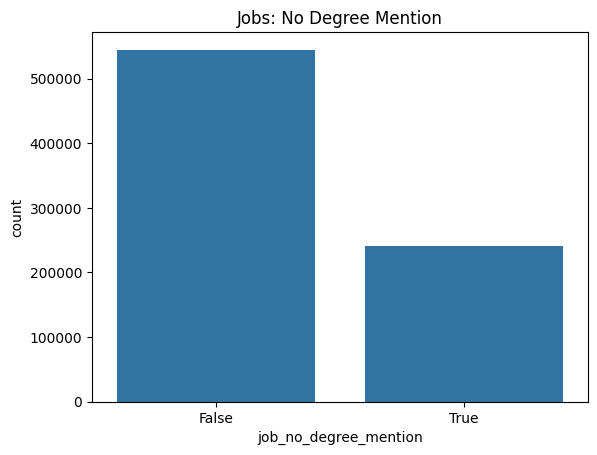

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# ======== Boolean Features ============
sns.countplot(x='job_work_from_home', data=jobs_df)
plt.title('Jobs: Work From Home Distribution')
plt.show()

sns.countplot(x='job_no_degree_mention', data=jobs_df)
plt.title('Jobs: No Degree Mention')
plt.show()


/tmp/ipython-input-3011727569.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_locations.index, x=top_locations.values, palette="viridis")


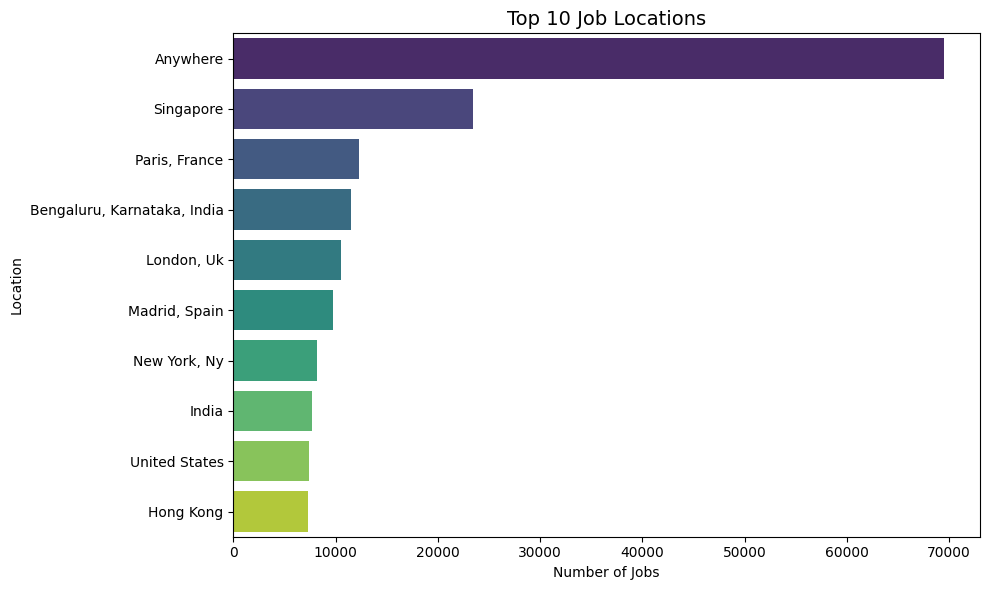

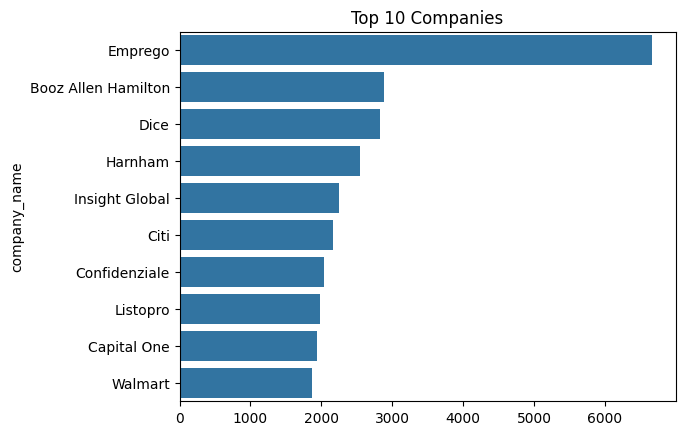

In [16]:
# ============= Top Locations & Companies ==============
top_locations = jobs_df['job_location'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(y=top_locations.index, x=top_locations.values, palette="viridis")
plt.title('Top 10 Job Locations', fontsize=14)
plt.xlabel('Number of Jobs')
plt.ylabel('Location')
plt.tight_layout()
plt.show()
top_companies = jobs_df['company_name'].value_counts().nlargest(10)
sns.barplot(x=top_companies.values, y=top_companies.index)
plt.title('Top 10 Companies')
plt.show()


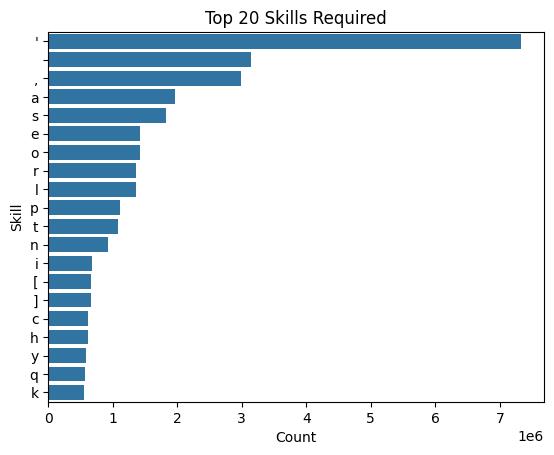

In [17]:
# ============= Skills Analysis ==============
from collections import Counter

all_skills = [skill for skills_list in jobs_df['job_skills'] for skill in skills_list]
top_skills = Counter(all_skills).most_common(20)

skills_df = pd.DataFrame(top_skills, columns=['Skill', 'Count'])
sns.barplot(x='Count', y='Skill', data=skills_df)
plt.title('Top 20 Skills Required')
plt.show()



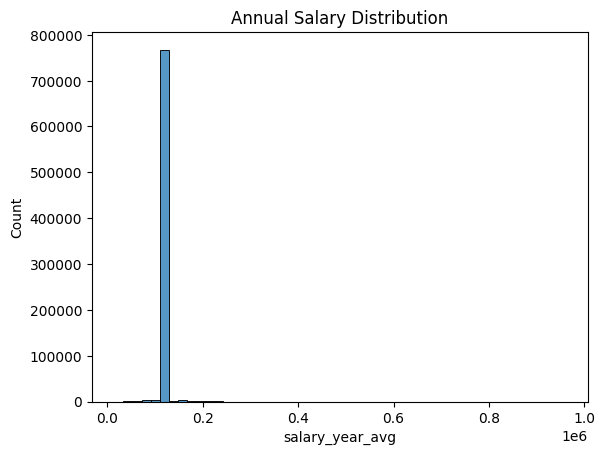

In [9]:
# ============= Salary Distribution ==============
sns.histplot(jobs_df['salary_year_avg'], bins=50)
plt.title('Annual Salary Distribution')
plt.show()


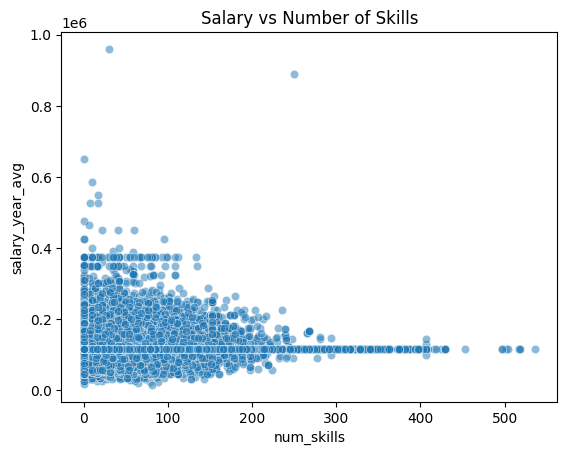

In [10]:
# ============= Skills vs Salary ==============
sns.scatterplot(x='num_skills', y='salary_year_avg', data=jobs_df, alpha=0.5)
plt.title('Salary vs Number of Skills')
plt.show()


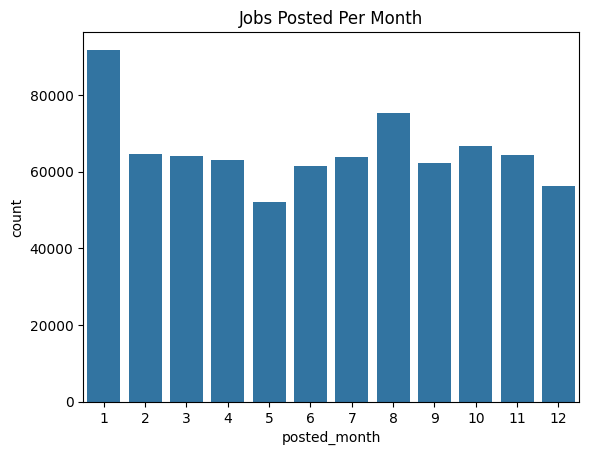

In [11]:
# ============= Jobs Over Time ==============
sns.countplot(x='posted_month', data=jobs_df)
plt.title('Jobs Posted Per Month')
plt.show()


Save the cleaned Dataset

In [18]:
jobs_df.to_csv("jobs_cleaned.csv", index=False)


In [19]:
from google.colab import files
files.download('jobs_cleaned.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>